[2026-08-05 17:39:06] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59


[2026-08-05 17:50:21] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 17:50:22] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 17:50:24] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 17:50:24] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 17:50:25] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 17:50:25] [info     ] ========== 数据检查 ==========
[2026-08-05 17:50:25] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset

时段,IC
2024-01-15~2024-02-08,0.0091
2024-09-24~2024-10-08,0.0389

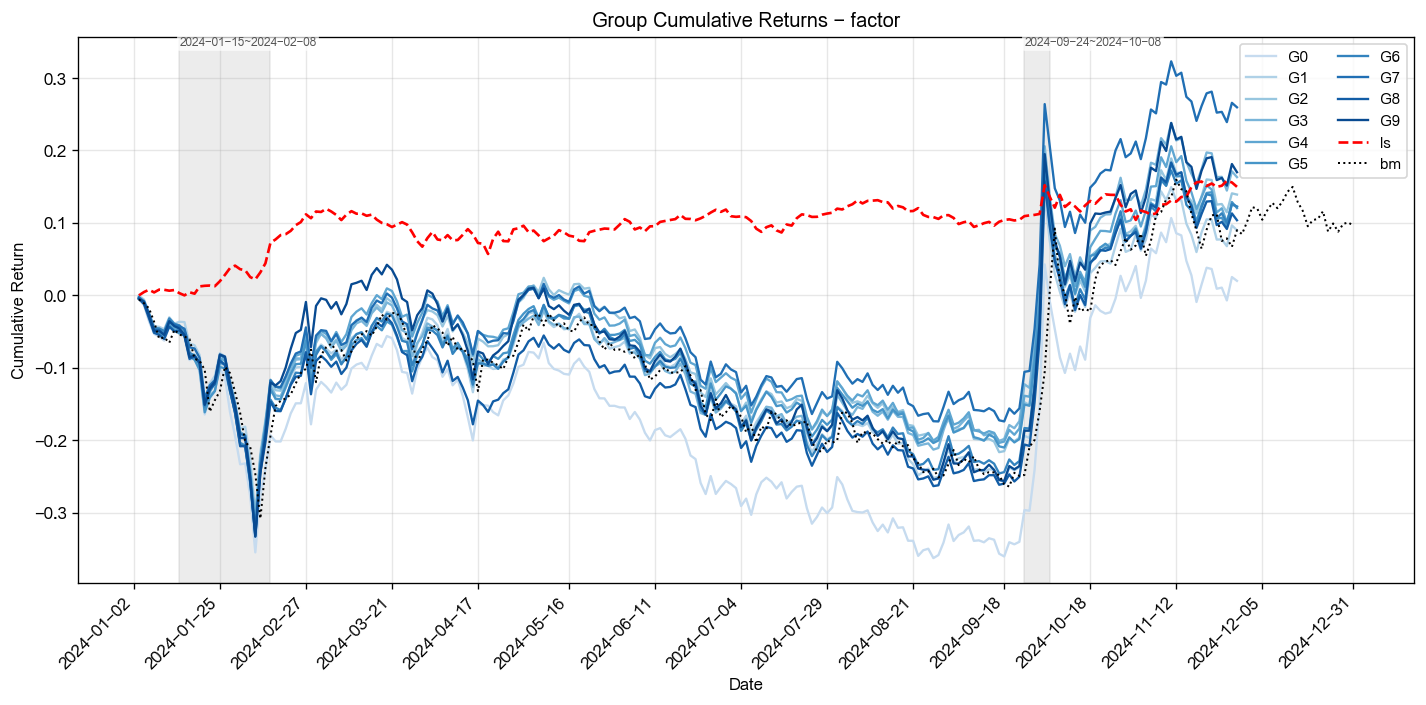
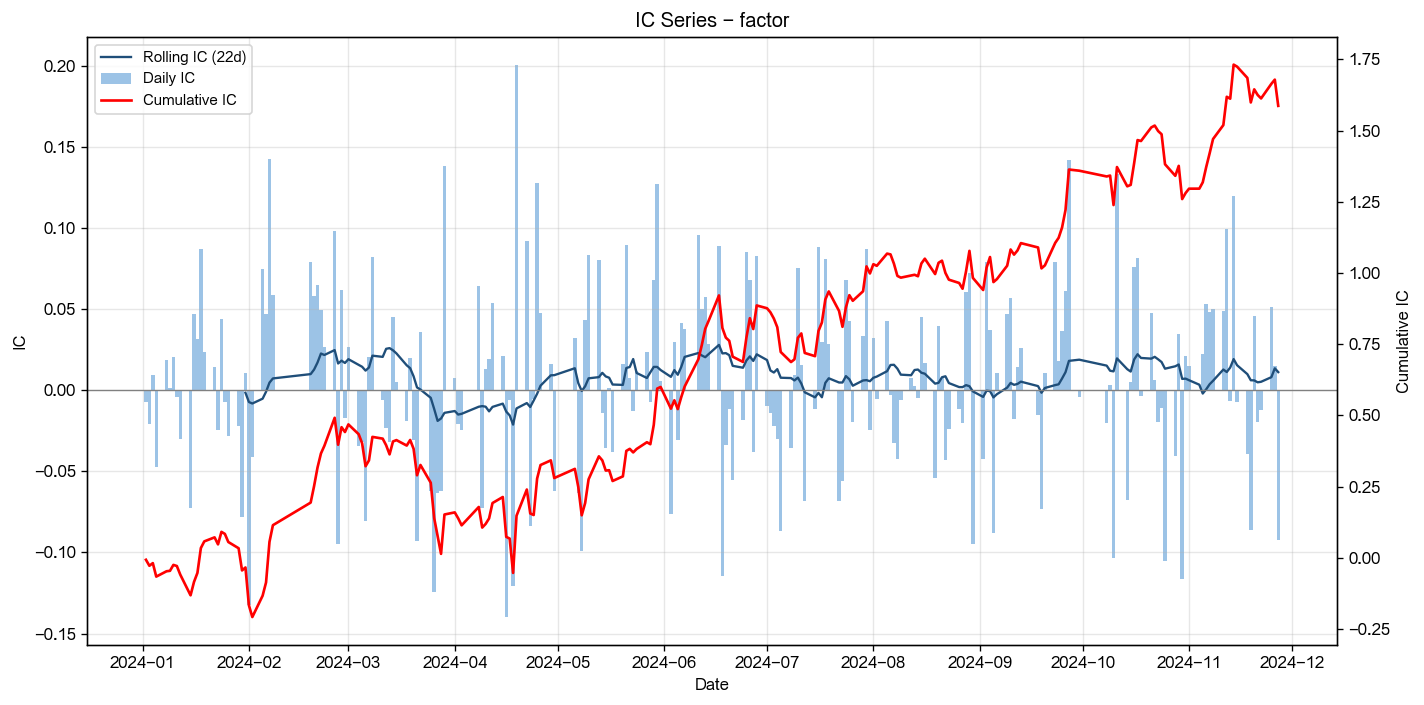
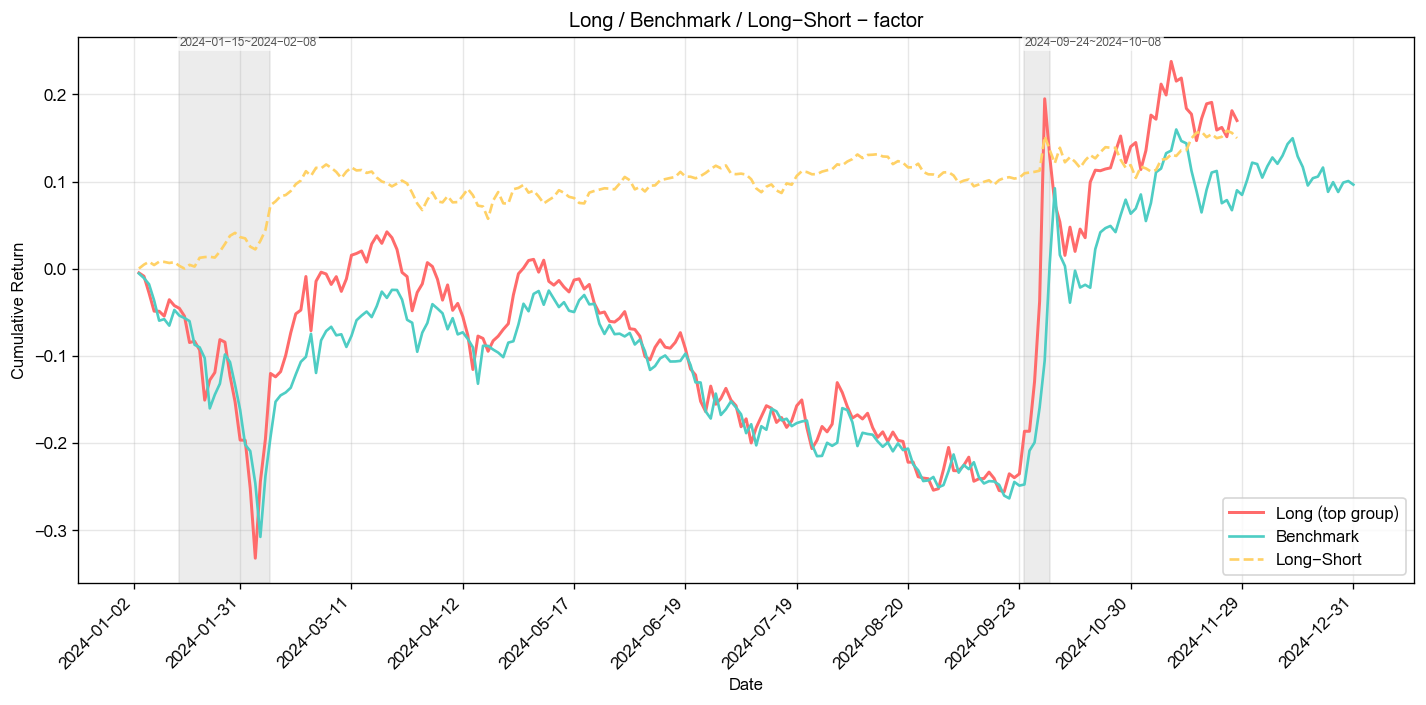
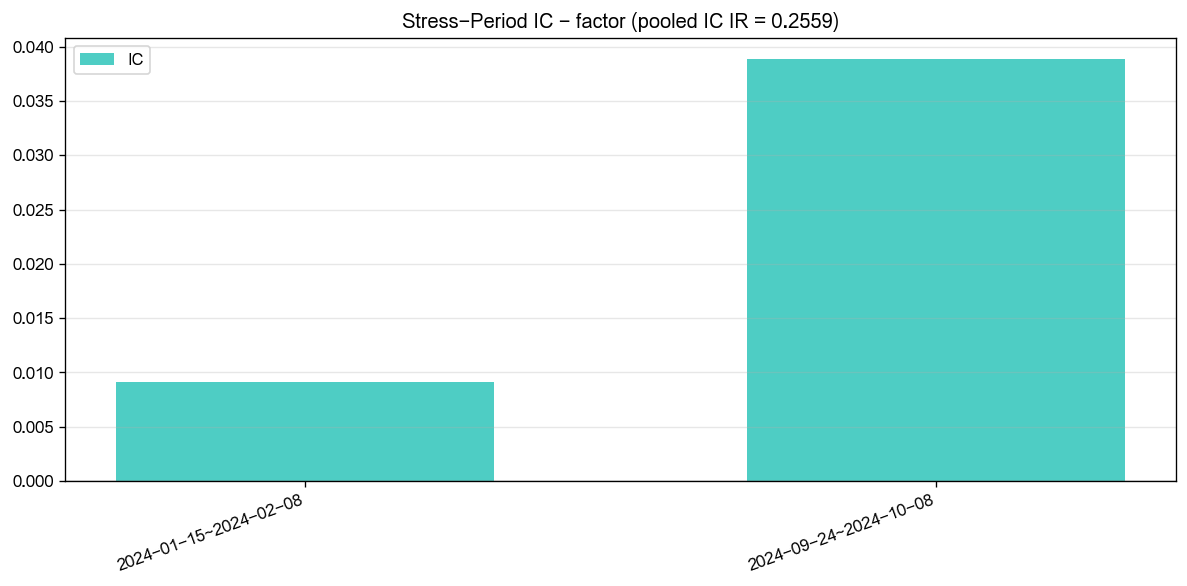
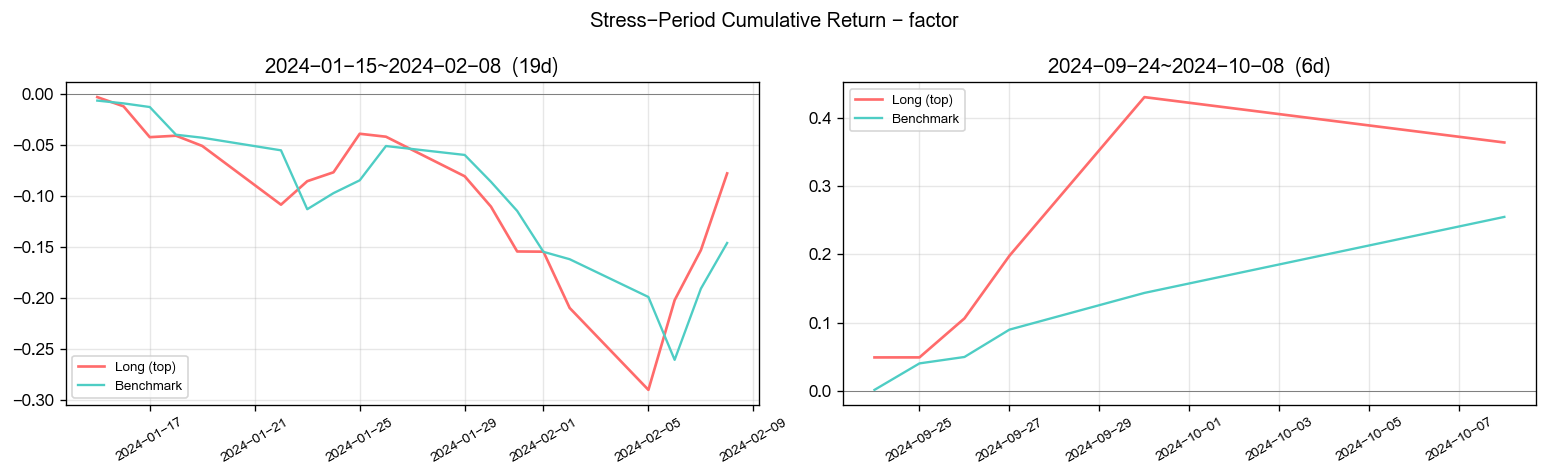

[2026-08-05 17:50:33] [info     ] ========== 因子池回归 ==========
[2026-08-05 17:50:33] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 17:50:34] [info     ] 获取收益率数据, 耗时: 0.7324 秒
[2026-08-05 17:50:34] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0738 秒
[2026-08-05 17:50:34] [info     ] 统计 回归结果, 耗时: 0.0269 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.8222,0.0451,0.0248,1.0000
2,amount,1.6420,0.0179,0.0109,0.9000
3,netflow_amount_rate_main,1.5400,0.0099,0.0064,1.0000
4,netflow_amount_main,1.4952,0.0251,0.0168,1.0000
5,gross_profit_rate_ttm,1.4844,0.0070,0.0047,1.0000
6,bias_20,1.4391,0.0295,0.0205,0.9000
7,net_profit_rate_ttm,1.4380,0.0040,0.0028,0.8000
8,pb,1.4296,0.0096,0.0067,1.0000
9,ps_ttm,1.3643,0.0038,0.0028,0.9000
10,volume,1.3441,0.0139,0.0103,0.9000

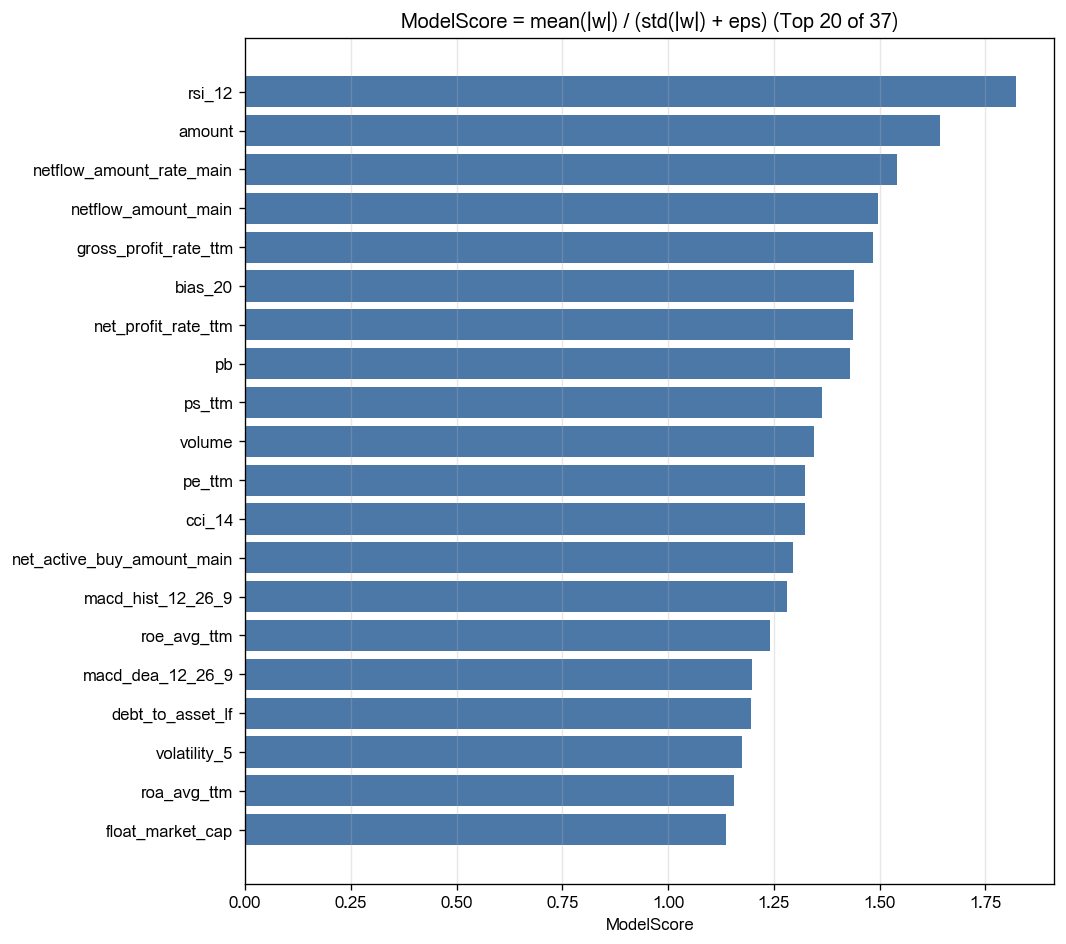
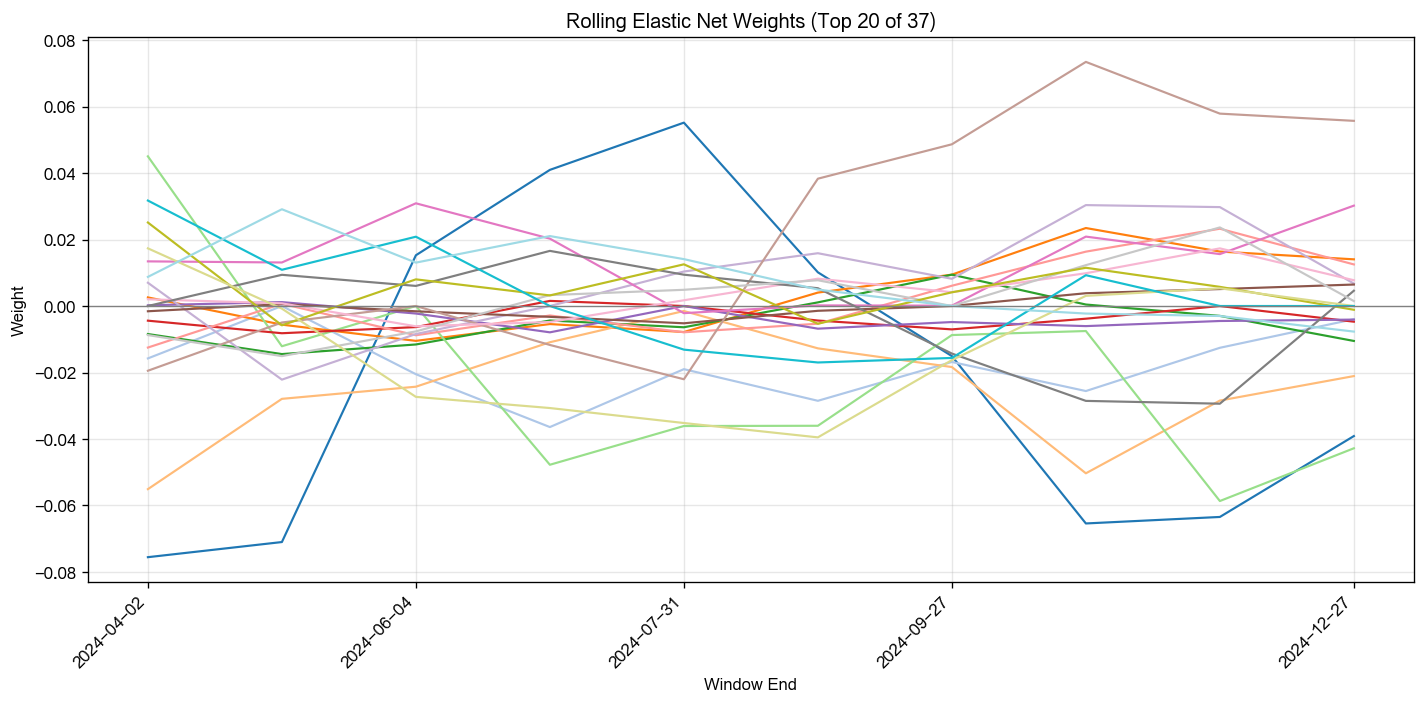
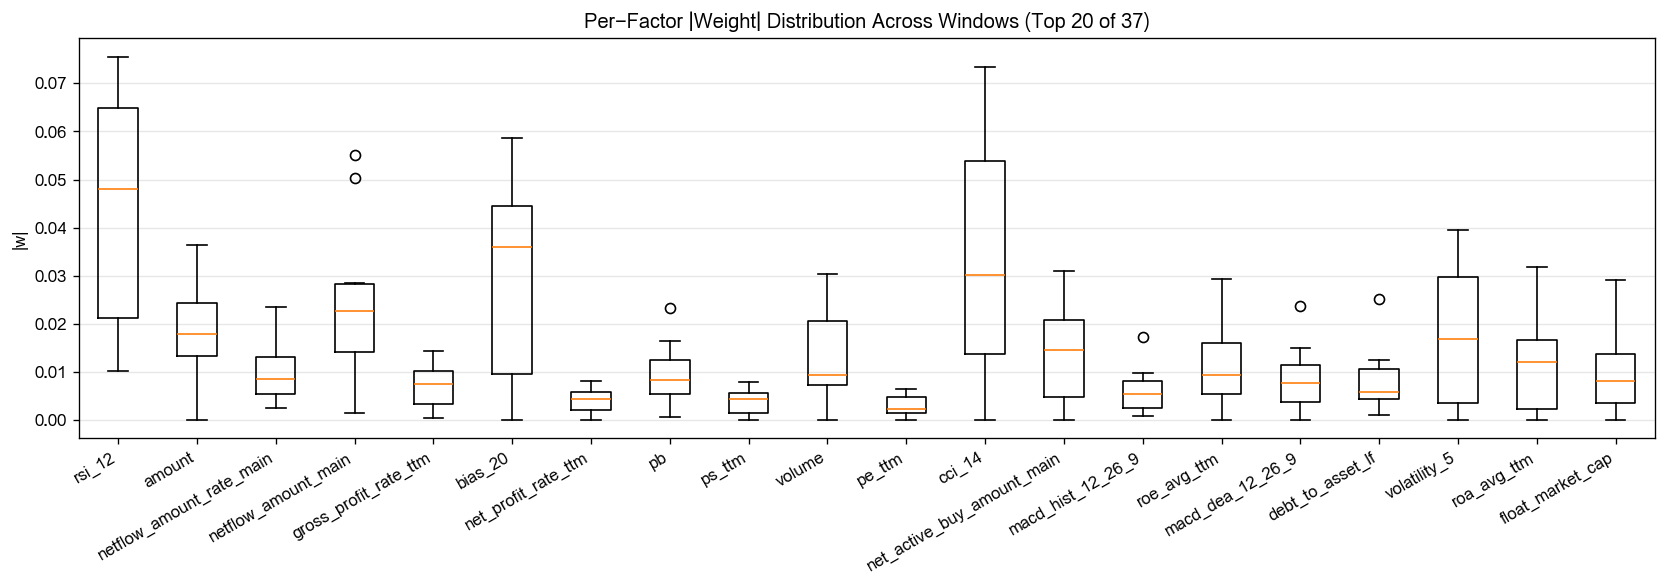
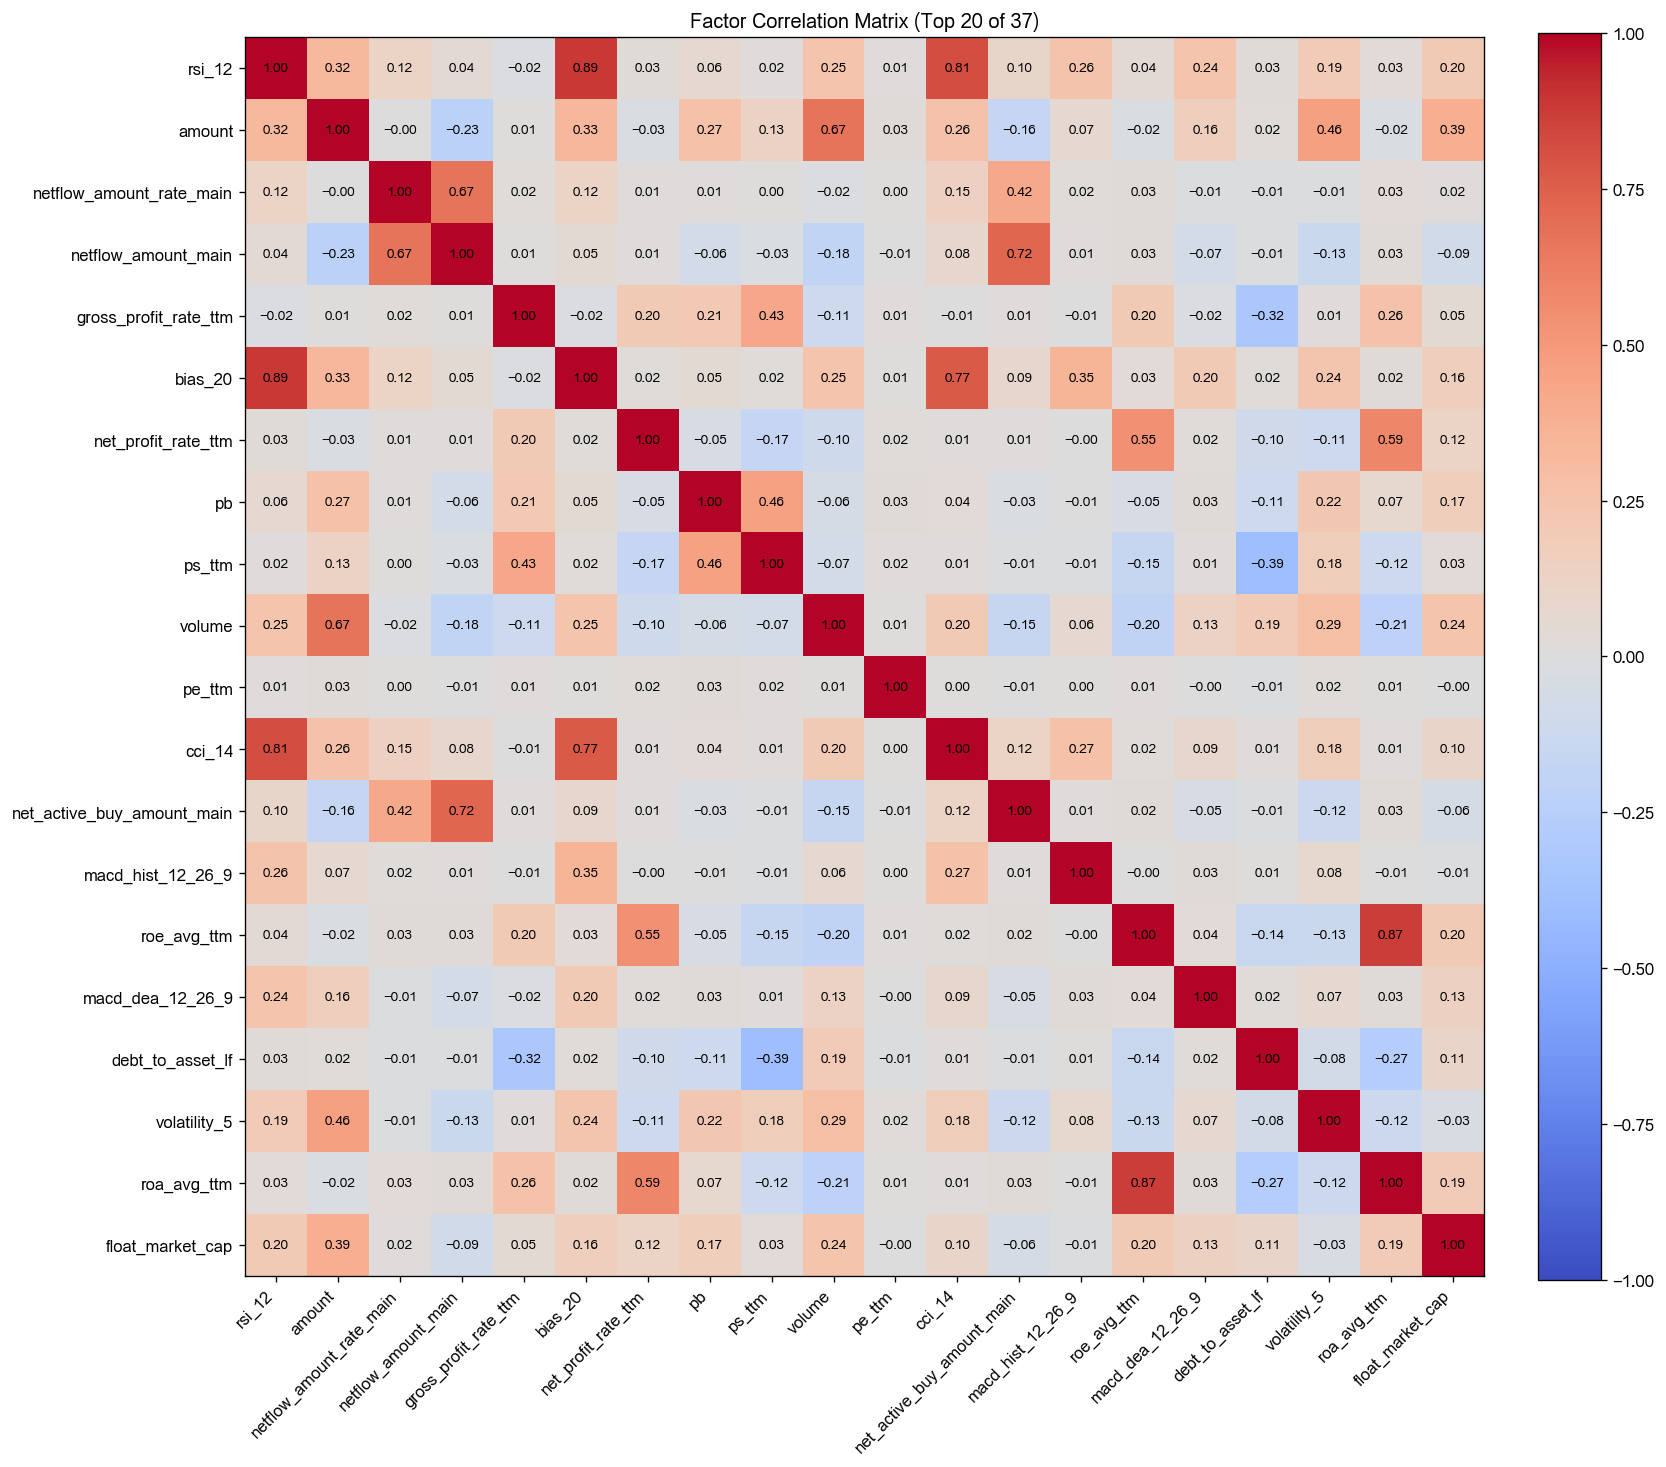

[2026-08-05 17:50:36] [warning  ] 返回的Outputs实例(size=34558557) 大于 64K, 将不会被缓存
[2026-08-05 17:50:36] [info     ] bigalpha_eval.v4 运行完成 [11.697s].


In [2]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数

    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}。一个因子可同时用到多张表，
                            通过逻辑名取出该阶段实际的物理表名，平台会在公榜/私榜自动切换。
                            当前可用逻辑名:
                                "bar1m"     -> 分钟 K 线表
                                "financial" -> 财务数据表
        start_date (str): 开始时间
        end_date (str):   结束时间

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import pandas as pd
    import dai

    # 从映射里取出本阶段实际的物理表名（切勿在 SQL 里硬编码表名，否则公榜/私榜无法切换）
    bar1m = datasources["bar1m"]
    financial_table = datasources["financial"]

    # 若计算滚动/时序类因子，可以多取若干天数据作为缓冲（本示例无需滚动，仅作演示）
    LOOKBACK_DAYS = 700
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    # ===== 编写因子 SQL =====
    # 示例因子：基于 1 分钟盘口快照计算日内订单簿压力，按交易日聚合为日频因子
    # DAI 函数文档：https://bigquant.com/wiki/doc/Rceb2JQBdS
    sql = f"""
    WITH cte_trading_days AS (
        SELECT DISTINCT
            instrument,
            CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS date
        FROM {bar1m}
    ),

    -- date 是公告日,report_date 是报告期。
    -- shift=0 只保留该公告日对应的当前报告。
    cte_fin_raw AS (
        SELECT
            instrument,
            CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS announcement_date,
            CAST(strftime(report_date, '%Y-%m-%d') AS DATETIME) AS report_date,
            total_assets,
            total_owner_equity,
            operating_profit,
            net_profit,
            operating_revenue,
            retained_income,
            working_capital,
            cash_balance_ending,
            depreciation_amortization,
            accounts_receivable,
            inventories,
            total_current_liabilities,
            period_shares,
            ROW_NUMBER() OVER (
                PARTITION BY instrument, strftime(date, '%Y-%m-%d')
                ORDER BY
                    report_date DESC,
                    date DESC,
                    total_assets DESC NULLS LAST,
                    total_owner_equity DESC NULLS LAST,
                    operating_profit DESC NULLS LAST,
                    operating_revenue DESC NULLS LAST,
                    period_shares DESC NULLS LAST
            ) AS rn
        FROM {financial_table}
        WHERE report_date IS NOT NULL
          AND COALESCE(shift, 0) = 0
    ),

    cte_fin_dedup AS (
        SELECT
            instrument,
            announcement_date,
            report_date,
            total_assets,
            total_owner_equity,
            operating_profit,
            net_profit,
            operating_revenue,
            retained_income,
            working_capital,
            cash_balance_ending,
            depreciation_amortization,
            accounts_receivable,
            inventories,
            total_current_liabilities,
            period_shares
        FROM cte_fin_raw
        WHERE rn = 1
    ),

    cte_fin_with_growth AS (
        SELECT
            *,
            COALESCE(
                (operating_revenue - LAG(operating_revenue, 4) OVER w)
                    / NULLIF(ABS(LAG(operating_revenue, 4) OVER w), 0),
                (operating_revenue - LAG(operating_revenue, 1) OVER w)
                    / NULLIF(ABS(LAG(operating_revenue, 1) OVER w), 0)
            ) AS rev_growth,
            COALESCE(
                (total_assets - LAG(total_assets, 4) OVER w)
                    / NULLIF(ABS(LAG(total_assets, 4) OVER w), 0),
                (total_assets - LAG(total_assets, 1) OVER w)
                    / NULLIF(ABS(LAG(total_assets, 1) OVER w), 0)
            ) AS asset_growth
        FROM cte_fin_dedup
        WINDOW w AS (
            PARTITION BY instrument
            ORDER BY report_date, announcement_date
        )
    ),

    -- 核心更正：公告日当天不可使用，映射到公告后的第一个交易日。
    cte_fin_effective_raw AS (
        SELECT
            f.*,
            (
                SELECT MIN(t.date)
                FROM cte_trading_days t
                WHERE t.instrument = f.instrument
                  AND t.date > f.announcement_date
            ) AS effective_date
        FROM cte_fin_with_growth f
    ),

    cte_fin_effective AS (
        SELECT *
        FROM (
            SELECT
                *,
                ROW_NUMBER() OVER (
                    PARTITION BY instrument, effective_date
                    ORDER BY
                        report_date DESC,
                        announcement_date DESC,
                        total_assets DESC NULLS LAST,
                        total_owner_equity DESC NULLS LAST,
                        operating_profit DESC NULLS LAST,
                        operating_revenue DESC NULLS LAST,
                        period_shares DESC NULLS LAST
                ) AS effective_rn
            FROM cte_fin_effective_raw
            WHERE effective_date IS NOT NULL
        )
        WHERE effective_rn = 1
    ),

    cte_fin_ffill AS (
        SELECT
            t.instrument,
            t.date,
            LAST(f.total_assets IGNORE NULLS) OVER w AS total_assets,
            LAST(f.total_owner_equity IGNORE NULLS) OVER w AS total_owner_equity,
            LAST(f.operating_profit IGNORE NULLS) OVER w AS operating_profit,
            LAST(f.operating_revenue IGNORE NULLS) OVER w AS operating_revenue,
            LAST(f.retained_income IGNORE NULLS) OVER w AS retained_income,
            LAST(f.working_capital IGNORE NULLS) OVER w AS working_capital,
            LAST(f.cash_balance_ending IGNORE NULLS) OVER w AS cash_balance_ending,
            LAST(f.depreciation_amortization IGNORE NULLS) OVER w AS depreciation_amortization,
            LAST(f.accounts_receivable IGNORE NULLS) OVER w AS accounts_receivable,
            LAST(f.inventories IGNORE NULLS) OVER w AS inventories,
            LAST(f.total_current_liabilities IGNORE NULLS) OVER w AS total_current_liabilities,
            LAST(f.period_shares IGNORE NULLS) OVER w AS period_shares,
            LAST(f.rev_growth IGNORE NULLS) OVER w AS rev_growth,
            LAST(f.asset_growth IGNORE NULLS) OVER w AS asset_growth
        FROM cte_trading_days t
        LEFT JOIN cte_fin_effective f
          ON t.instrument = f.instrument
         AND t.date = f.effective_date
        WINDOW w AS (
            PARTITION BY t.instrument
            ORDER BY t.date
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        )
    ),

    -- 对相同时间戳的分钟记录先做确定性去重
    cte_bar1m_ranked AS (
        SELECT
            date,
            instrument,
            open,
            close,
            volume,
            amount,
            ROW_NUMBER() OVER (
                PARTITION BY instrument, date
                ORDER BY
                    close DESC NULLS LAST,
                    open DESC NULLS LAST,
                    volume DESC NULLS LAST,
                    amount DESC NULLS LAST
            ) AS minute_rn
        FROM {bar1m}
        WHERE volume > 0 AND amount > 0
    ),

    cte_bar1m_base AS (
        SELECT date, instrument, open, close, volume, amount
        FROM cte_bar1m_ranked
        WHERE minute_rn = 1
    ),

    cte_bar1m_minute AS (
        SELECT
            date,
            instrument,
            open,
            close,
            volume,
            amount,
            CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS trading_date,
            LAG(close, 1) OVER (
                PARTITION BY instrument, strftime(date, '%Y-%m-%d')
                ORDER BY date
            ) AS prev_close
        FROM cte_bar1m_base
    ),

    cte_bar1m_daily AS (
        SELECT
            instrument,
            trading_date AS date,
            LAST(close ORDER BY date) AS daily_close,
            FIRST(open ORDER BY date) AS daily_open,
            SUM(amount) AS total_amount,
            STDDEV(
                CASE
                    WHEN prev_close > 0 THEN (close - prev_close) / prev_close
                    ELSE NULL
                END
            ) AS intraday_vol
        FROM cte_bar1m_minute
        GROUP BY instrument, trading_date
    ),

    cte_daily_ret AS (
        SELECT
            *,
            CASE
                WHEN LAG(daily_close, 1) OVER w > 0
                THEN daily_close / LAG(daily_close, 1) OVER w - 1.0
                ELSE NULL
            END AS daily_ret
        FROM cte_bar1m_daily
        WINDOW w AS (PARTITION BY instrument ORDER BY date)
    ),

    cte_daily_rolling AS (
        SELECT
            instrument,
            date,
            daily_close,
            total_amount,
            intraday_vol,
            CASE
                WHEN STDDEV(daily_ret) OVER w20 > 0
                 AND AVG(total_amount) OVER w20 > 0
                THEN LN(AVG(total_amount) OVER w20)
                     / NULLIF(LN(STDDEV(daily_ret) OVER w20), 0)
                ELSE NULL
            END AS trading_liquidity,
            CASE
                WHEN LAG(daily_close, 130) OVER w > 0
                 AND LAG(daily_close, 22) OVER w > 0
                THEN LAG(daily_close, 22) OVER w
                     / LAG(daily_close, 130) OVER w - 1.0
                ELSE NULL
            END AS mom_6m,
            CASE
                WHEN LAG(daily_close, 250) OVER w > 0
                 AND LAG(daily_close, 22) OVER w > 0
                THEN LAG(daily_close, 22) OVER w
                     / LAG(daily_close, 250) OVER w - 1.0
                ELSE NULL
            END AS mom_12m
        FROM cte_daily_ret
        WINDOW
            w AS (PARTITION BY instrument ORDER BY date),
            w20 AS (
                PARTITION BY instrument
                ORDER BY date
                ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
            )
    ),

    cte_features_raw AS (
        SELECT
            b.instrument,
            b.date,
            CASE
                WHEN f.total_assets > 0
                 AND f.period_shares > 0
                 AND b.daily_close > 0
                 AND f.total_assets - COALESCE(f.total_owner_equity, 0)
                     + f.period_shares * b.daily_close > 0
                THEN LN(
                    (f.total_assets - COALESCE(f.total_owner_equity, 0)
                     + f.period_shares * b.daily_close)
                    / f.total_assets
                )
                ELSE NULL
            END AS q,
            f.operating_profit / NULLIF(f.total_assets, 0) AS feat_roa,
            f.rev_growth AS feat_rev_growth,
            f.asset_growth AS feat_asset_growth,
            f.retained_income / NULLIF(f.total_assets, 0) AS feat_retained_ratio,
            f.depreciation_amortization / NULLIF(f.total_assets, 0) AS feat_deprec_ratio,
            f.working_capital / NULLIF(f.total_assets, 0) AS feat_wc_ratio,
            f.cash_balance_ending / NULLIF(f.total_assets, 0) AS feat_cash_to_asset,
            f.cash_balance_ending / NULLIF(f.total_current_liabilities, 0) AS feat_cash_ratio,
            (COALESCE(f.cash_balance_ending, 0) + COALESCE(f.accounts_receivable, 0))
                / NULLIF(f.total_current_liabilities, 0) AS feat_quick_ratio,
            (COALESCE(f.cash_balance_ending, 0) + COALESCE(f.accounts_receivable, 0)
             + COALESCE(f.inventories, 0))
                / NULLIF(f.total_current_liabilities, 0) AS feat_current_ratio,
            b.trading_liquidity AS feat_trading_liq,
            b.intraday_vol AS feat_market_risk,
            LN(NULLIF(f.total_assets, 0)) AS feat_size,
            b.mom_6m AS feat_mom_6m,
            b.mom_12m AS feat_mom_12m
        FROM cte_daily_rolling b
        LEFT JOIN cte_fin_ffill f
          ON b.instrument = f.instrument
         AND b.date = f.date
    ),

    cte_features_std AS (
        SELECT
            instrument,
            date,
            q,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_roa - AVG(feat_roa) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_roa) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_roa) OVER w ELSE 1.0 END)), 0) AS z_profitability,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_rev_growth - AVG(feat_rev_growth) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_rev_growth) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_rev_growth) OVER w ELSE 1.0 END)), 0) AS z_rev_growth,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_asset_growth - AVG(feat_asset_growth) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_asset_growth) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_asset_growth) OVER w ELSE 1.0 END)), 0) AS z_asset_growth,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_retained_ratio - AVG(feat_retained_ratio) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_retained_ratio) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_retained_ratio) OVER w ELSE 1.0 END)), 0) AS z_retained_ratio,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_deprec_ratio - AVG(feat_deprec_ratio) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_deprec_ratio) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_deprec_ratio) OVER w ELSE 1.0 END)), 0) AS z_deprec_ratio,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_wc_ratio - AVG(feat_wc_ratio) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_wc_ratio) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_wc_ratio) OVER w ELSE 1.0 END)), 0) AS z_wc_ratio,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_cash_to_asset - AVG(feat_cash_to_asset) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_cash_to_asset) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_cash_to_asset) OVER w ELSE 1.0 END)), 0) AS z_cash_to_asset,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_cash_ratio - AVG(feat_cash_ratio) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_cash_ratio) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_cash_ratio) OVER w ELSE 1.0 END)), 0) AS z_cash_ratio,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_quick_ratio - AVG(feat_quick_ratio) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_quick_ratio) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_quick_ratio) OVER w ELSE 1.0 END)), 0) AS z_quick_ratio,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_current_ratio - AVG(feat_current_ratio) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_current_ratio) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_current_ratio) OVER w ELSE 1.0 END)), 0) AS z_current_ratio,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_trading_liq - AVG(feat_trading_liq) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_trading_liq) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_trading_liq) OVER w ELSE 1.0 END)), 0) AS z_trading_liq,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_market_risk - AVG(feat_market_risk) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_market_risk) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_market_risk) OVER w ELSE 1.0 END)), 0) AS z_market_risk,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_size - AVG(feat_size) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_size) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_size) OVER w ELSE 1.0 END)), 0) AS z_size,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_mom_6m - AVG(feat_mom_6m) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_mom_6m) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_mom_6m) OVER w ELSE 1.0 END)), 0) AS z_mom_6m,
            COALESCE(GREATEST(-3.0, LEAST(3.0,
                (feat_mom_12m - AVG(feat_mom_12m) OVER w)
                / CASE WHEN COALESCE(STDDEV(feat_mom_12m) OVER w, 0) > 1e-12
                       THEN STDDEV(feat_mom_12m) OVER w ELSE 1.0 END)), 0) AS z_mom_12m
        FROM cte_features_raw
        WINDOW w AS (PARTITION BY date)
    ),

    cte_category_factors AS (
        SELECT
            instrument,
            date,
            q,
            z_profitability AS f_profit,
            (z_rev_growth + z_asset_growth) / 2.0 AS f_growth,
            (z_retained_ratio + z_deprec_ratio) / 2.0 AS f_invest,
            (z_wc_ratio + z_cash_to_asset + z_cash_ratio
             + z_quick_ratio + z_current_ratio) / 5.0 AS f_op_liq,
            z_trading_liq AS f_trd_liq,
            z_market_risk AS f_mkt_risk,
            z_size AS f_size,
            (z_mom_6m + z_mom_12m) / 2.0 AS f_momentum,
            AVG(q) OVER (PARTITION BY date) AS q_bar
        FROM cte_features_std
    ),

    cte_residual AS (
        SELECT
            instrument,
            date,
            COALESCE(q, q_bar) - (
                q_bar
                + 0.25 * f_profit
                + 0.13 * f_growth
                + 0.07 * f_invest
                + 0.07 * f_op_liq
                + 0.46 * f_trd_liq
                + 0.17 * f_mkt_risk
                - 0.50 * f_size
                + 0.13 * f_momentum
            ) AS e
        FROM cte_category_factors
    ),

    cte_urvaf AS (
        SELECT
            instrument,
            date,
            -(e - AVG(e) OVER (
                PARTITION BY instrument
                ORDER BY date
                ROWS BETWEEN 149 PRECEDING AND CURRENT ROW
            )) AS factor
        FROM cte_residual
    ),

    cte_dedup AS (
        SELECT
            date, instrument, MAX(factor) AS factor
        FROM cte_urvaf
        WHERE factor IS NOT NULL
        GROUP BY date, instrument
    )

    SELECT date, instrument, factor
    FROM cte_dedup
    """
    # ===== 调用dai计算因子 =====
    # compression=True 会把 instrument 列转为 category 类型，显著降低内存占用
    # ===== 调用 dai 计算因子 =====
    # 传入 query_start_date 确保 MA5 滚动计算有足够的前置历史缓冲数据，避免因子在区间起点发生数据截断
    df = dai.query(
        sql,
        filters={'date': [query_start_date.strftime('%Y-%m-%d %H:%M:%S'), end_date]},
        compression=True,
    ).df()

    # ✅ 算完因子后，把输出裁回真正的评估区间 [start_date, end_date]
    df = df[(df['date'] >= pd.to_datetime(start_date)) & (df['date'] <= pd.to_datetime(end_date))]

    # ===== 对齐股票池 =====
    # 数据源保留了 2019 年至今所有成分股的数据以便计算时序因子，
    # 因此需与中证 1000 成分股做内连接，只保留当日属于成分股的标的
    # bigalpha_2026_instruments 已经收录了2019年以来的所有数据，不用替换
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    df = pd.merge(df, stk_pool, how='inner', on=['date', 'instrument'])

    return df

